# Microbiome age model

# Import Package

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import joblib
import os
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight
from joblib import dump
from joblib import load
from scipy.stats import pearsonr
import shap
import re
from sklearn.model_selection import LeaveOneOut, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, PredictionErrorDisplay


# Import Data

In [ ]:
table_path = 'data/2_preprocessed/log1p/prv10_ft_log1p_control.tsv'
meta_path = 'data/pre_metadata.tsv'
shannon = 'data/2_preprocessed/diversity/shannon_table.tsv'
table = pd.read_csv(table_path, sep='\t', index_col=0)
meta = pd.read_csv(meta_path, sep='\t').set_index("#SampleID")
shannon = pd.read_csv(shannon, sep='\t').set_index("#SampleID")

meta = meta[(meta["Host_disease"]) == "Control"]
common = table.index.intersection(meta.index)


meta = meta.loc[common]
Months_series = meta['Months']

X_df = table.merge(shannon["shannon_entropy"], left_index=True, right_index=True)
y_series = meta['Months']

print("X shape", X_df.shape)
print("y shape", y_series.shape)    

X shape (94, 190)
y shape (94,)


In [62]:
X_df

,d__Bacteria;__;__;__;__;__,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029;g__Escherichia,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae_A_595427;g__Sutterella,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Gemmiger_A_73129,d__Archaea;p__Methanobacteriota_A_1229;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter_A,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides_H_857956,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Chitinophagales;f__Chitinophagaceae;g__Hydrotalea,d__Bacteria;p__Actinomycetota;c__Actinomycetes;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium_388775,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Enterococcaceae;g__Enterococcus_B,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Lachnospirales;f__Lachnospiraceae;g__Blautia_A_141780,...,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae_A_595427;g__Parasutterella_564865,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae_A_595421;g__Oxalobacter,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__UMGS1071,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__Hydrogeniiclostridium,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Negativibacillus,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__QAKW01;g__,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__Clostridium_A_51961,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Monoglobales;f__Monoglobaceae;g__Monoglobus,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Ruminiclostridium_E,shannon_entropy
#SampleID,,,,,,,,,,,,,,,,,,,,,
SRR23478191,0.000000,4.795791,0.000000,0.000000,0.000000,5.247024,0.000000,3.178054,5.762051,1.945910,...,5.796058,0.000000,2.564949,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.522555
SRR23478195,0.693147,4.890349,0.000000,0.693147,0.693147,1.098612,0.000000,5.043425,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.114460
SRR23478196,1.098612,5.796058,0.000000,0.000000,0.000000,1.098612,0.000000,6.684612,0.693147,3.761200,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.922392
SRR23478197,0.000000,3.663562,0.000000,0.693147,0.000000,5.926926,0.000000,7.128496,0.693147,0.000000,...,0.000000,0.000000,1.791759,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.599100
SRR23478198,0.000000,2.995732,0.000000,0.000000,0.000000,2.302585,0.000000,5.560682,0.000000,3.610918,...,0.000000,0.000000,2.397895,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.197447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR23478290,3.135494,5.749393,0.000000,6.630683,0.000000,5.117994,0.000000,6.244167,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,5.982686
SRR23478291,0.000000,0.000000,0.000000,6.680855,0.000000,5.655992,1.098612,5.828946,0.000000,0.000000,...,2.197225,0.000000,1.945910,0.000000,0.000000,0.000000,0.000000,1.386294,3.931826,5.235967
SRR23478292,0.000000,6.120297,1.791759,4.418841,0.000000,6.745236,0.693147,3.295837,0.000000,0.000000,...,1.386294,1.098612,2.397895,0.000000,0.000000,1.386294,0.000000,0.000000,0.693147,5.549139


# 1. Model Develop

- Microbiome age model packaging code block.
- Hyperparameter search -> Train:Test dataset separation(8:2) -> Train dataset use CV -> results plot(train dataset) -> train dataset CV importance feature list save -> importance feature use train dataset CV results -> importance feature use test dataset results -> Finally whole dataset use training model -> Final model(microbiome age model) SHAP analysis -> Train CV, Test results file save.

In [63]:
## plot properties setting
plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.linewidth'] = 0.6  

In [ ]:
class MicrobiomeAgeModel:
    """
    Use Random Forest Regression to analyze microbiome Data.
    Cross-validation -> Feature selection -> Model interpretation (SHAP)
    """

    def __init__(self, n_top_features=30, random_state=1234, n_splits_grid_search=5, test_size = 0.2):
        """
        Args:
            n_estimators (int): Tree of Random Forest
            n_top_features (int): Number of top features to select
            random_state (int): Seed value for reproducibility
            test_size (float): separation by train / test dataset
        """
        self.n_top_features = n_top_features
        self.random_state = random_state
        self.n_splits_grid_search = n_splits_grid_search
        self.test_size = test_size
        self.model = None  # To be initialized to optimal parameters
        self.best_params = None
        self.feature_names = None
        self.top_features_indices = None
        self.top_features_names = None
        self.final_model = None
        self.model_results = None

    @staticmethod
    def _simplify_taxonomy(name: str) -> str:
        """
        If have genus label, changed to genus label.
        If taxonomy doesn't have genus label, f__ → o__ → c__ → p__ upper-level unclassified genus return.
        """
        if not isinstance(name, str) or ';' not in name:
            return name

        levels = [level.strip() for level in name.split(';') if level.strip()]

        tax_map = {}
        for level in levels:
            if '__' in level:
                prefix, value = level.split('__', 1)
                tax_map[prefix] = value.strip()

        def upper_label(ranks):
            for r in ranks:
                val = tax_map.get(r, '')
                if val:
                    return val
            return "Unknown"
            

        # 1. If have genus label, delete to g__ and return to genus label.
        g_val = tax_map.get('g', '')
        if g_val:
            return g_val

        # 2. If don't have genus label, family/order/class/phylum criteria applied and return to unclassified genus.
        upper = upper_label(['f', 'o', 'c', 'p'])

        return f"{upper} unclassified genus"
    
    def _phylum_taxonomy(name: str) -> str:
        """Phylum"""
        if not isinstance(name, str) or ';' not in name:
            return name
        levels = name.split(';')
        selected = [level.strip() for level in levels if level.strip().startswith(('p__'))]
        return '; '.join(selected)

    def find_best_hyperparameters(self, X: pd.DataFrame, y: pd.Series):
        #GridSearchCV Use and find the best hyperparameters for Random Forest Regressor.
        print("Start to GridSearchCV by train data")
        
        # Hyperparamter list
        param_grid = {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 20, 30],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
        
        # GridSearchCV setting
        # Notification: You use large of data, decrease to KFold n_splits.
        cv_grid = KFold(n_splits=self.n_splits_grid_search, shuffle=True, random_state=self.random_state)
        
        rf = RandomForestRegressor(random_state=self.random_state, n_jobs=20)
        
        grid_search = GridSearchCV(
            estimator=rf,
            param_grid=param_grid,
            cv=cv_grid,
            scoring='neg_mean_squared_error',
            n_jobs=20,
            verbose=1 # progress output
        )
        
        grid_search.fit(X, y)
        
        self.best_params = grid_search.best_params_
        print(f"Find best parameter: {self.best_params}")
        
        # Model update
        self.model = RandomForestRegressor(**self.best_params, random_state=self.random_state, n_jobs=20)


    def run_cross_validation(self, X: np.ndarray, y: np.ndarray) -> tuple:
        #K-fold(n=5) to collect predictions and feature importances.
        if self.model is None:
            raise ValueError("First, activate find_best_hyperparameters")
        ## if model not reset, we activate first find_best_hyperparameters function.

        print("Start to 5-fold by train data")
        
        fold_y_true = []
        fold_y_pred = []
        all_pos = [] #CV results save
        importances_list = []

        kf = KFold(n_splits=5, shuffle=True, random_state=self.random_state)
        for fold_i, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]


            # Each CV fold, create hyperparamter model and training.
            fold_model = RandomForestRegressor(**self.best_params, random_state=self.random_state, n_jobs=20)
            fold_model.fit(X_train, y_train)
            
            # Save to prediction value and feature importance
            fold_y_true.append(y_test)
            fold_y_pred.append(fold_model.predict(X_test))
            all_pos.extend(test_idx)
            importances_list.append(fold_model.feature_importances_)
        
        print("train data 5-fold Complete")
        return fold_y_true, fold_y_pred, np.array(importances_list), np.array(all_pos)
    

    def evaluate_performance(self, y_true: np.ndarray, y_pred: np.ndarray, model_name: str, stage: str = "train", hue_data: pd.Series = None, save: bool = True):
        # Evaluate the model's performance and print the results.
        if stage == "train":
            stage_label = "Traindata"
        elif stage == "test":
            stage_label = "Testdata"
        else:
            stage_label = stage

        print(f"\n--- Transfer months to year {model_name} model---")

        y_true_year = (y_true / 12) - 0.5
        y_pred_year = (y_pred / 12) - 0.5
    
        
        print(f"\n--- Traindata {model_name} model evaluation ---")
        rmse = np.sqrt(mean_squared_error(y_true_year, y_pred_year))
        mae = mean_absolute_error(y_true_year, y_pred_year)
        r, p_value = pearsonr(y_true_year, y_pred_year)
        r2 = r2_score(y_true_year, y_pred_year)

        print(f"{stage_label} CV R²: {r2:.2f}")
        print(f"{stage_label} CV Pearson coefficient (R): {r:.2f} (p-value: {p_value:.4g})")
        print(f"{stage_label} CV RMSE: {rmse:.2f}")
        print(f"{stage_label} CV MAE: {mae:.2f}")
        
        # visualization logic
        plot_data = pd.DataFrame({
            'y_true': y_true,
            'y_pred': y_pred,
            'y_true_year': y_true_year,
            'y_pred_year': y_pred_year,
        })


        if hue_data is not None:
            plot_data[hue_data.name] = hue_data.reset_index(drop=True)


        if save:
            safe_name = (
                model_name.lower()
                .replace(" ", "_")
                .replace("(", "")
                .replace(")", "")
            )

        plt.figure(figsize=(3.25,3.25))
        sns.scatterplot(data=plot_data, x='y_true_year', y='y_pred_year', color='#326a81', alpha=0.8)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlim(0,18)
        plt.ylim(0,18)
        plt.xticks(range(0, 18, 3))
        plt.yticks(range(0, 18, 3))
        plt.plot([1,17], [1,17], '--', color='gray')
        metrics_text = (
            f"R² = {r2:.2f}\n"
            f"Pearson correlation= {r:.2f}\n"
            f"RMSE = {rmse:.2f}\n"
            f"MAE = {mae:.2f}"
            )
        plt.text(0.98, 0.98, metrics_text, transform=plt.gca().transAxes, ha='right', va='top', fontsize=7)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.title(f'Test data MMI', fontweight='bold')
        plt.xlabel('Actual Age', fontweight='bold')
        plt.ylabel('MMI', fontweight='bold')
        plt.grid()
        fname = f"figure/1_microbiome_age_model/{stage_label}_year.pdf"
        plt.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"[Saved]{fname}")
        plt.show()
        


    def evaluate_performance_cv(self, fold_y_true, fold_y_pred, model_name: str, stage: str = "train", hue_data: pd.Series = None, save: bool = True):
        # Evaluate the model's performance and print the results.
        if stage == "train":
            stage_label = "Traindata"
        elif stage == "test":
            stage_label = "Validation"
        else:
            stage_label = stage
        
        r2s, rs, pvals, rmses, maes = [], [], [], [], []

        for yt, yp in zip(fold_y_true, fold_y_pred):

            yt_year = (yt / 12) - 0.5
            yp_year = (yp / 12) - 0.5

            rmse = np.sqrt(mean_squared_error(yt_year, yp_year))
            mae = mean_absolute_error(yt_year, yp_year)
            r, p_value = pearsonr(yt_year, yp_year)
            r2 = r2_score(yt_year, yp_year)

            rmses.append(rmse)
            maes.append(mae)
            rs.append(r)
            pvals.append(p_value)
            r2s.append(r2)
        

        def mean_std(x):
            x = np.array(x, dtype=float)
            return x.mean(), x.std(ddof=1) if len(x) > 1 else 0.0
        
        rmse_m, rmse_s = mean_std(rmses)
        mae_m, mae_s = mean_std(maes)
        r_m, r_s = mean_std(rs)
        r2_m, r2_s = mean_std(r2s)

        print(f"\n--- {stage_label} | {model_name} model evaluation (fold-wise mean±sd) ---")

        print(f"{stage_label} CV R²: {r2_m:.2f} ± {r2_s:.2f}")
        print(f"{stage_label} CV Pearson correlation: {r_m:.2f} ± {r_s:.2f}")
        print(f"{stage_label} CV RMSE: {rmse_m:.2f} ± {rmse_s:.2f}")
        print(f"{stage_label} CV MAE: {mae_m:.2f} ± {mae_s:.2f}")

        y_true_flat = np.concatenate(fold_y_true)
        y_pred_flat = np.concatenate(fold_y_pred)

        # visualization logic
        plot_data = pd.DataFrame({
            'y_true': y_true_flat,
            'y_pred': y_pred_flat,
            'y_true_year': (y_true_flat / 12) - 0.5,
            'y_pred_year': (y_pred_flat / 12) - 0.5,
        })

        if hue_data is not None:
            # hue_data index matched y_true, y_pred by use reset_index
            plot_data[hue_data.name] = hue_data.reset_index(drop=True)

        if save:

            safe_name = (
                model_name.lower()
                .replace(" ", "_")
                .replace("(", "")
                .replace(")", "")
            )

        plt.figure(figsize=(3.25,3.25))
        sns.scatterplot(data=plot_data, x='y_true_year', y='y_pred_year', color = '#326a81', alpha=0.8)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlim(0,18)
        plt.ylim(0,18)
        plt.xticks(range(0, 18, 3))
        plt.yticks(range(0, 18, 3))
        plt.plot([1,17], [1,17], '--', color='gray')
        metrics_text = (
            f"R² = {r2_m:.2f} ± {r2_s:.2f}\n"
            f"Pearson correlation = {r_m:.2f} ± {r_s:.2f}\n"
            f"RMSE = {rmse_m:.2f} ± {rmse_s:.2f}\n"
            f"MAE = {mae_m:.2f} ± {mae_s:.2f}"
            )
        plt.text(0.98, 0.98, metrics_text, transform=plt.gca().transAxes, ha='right', va='top', fontsize=7)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.title(f'5-fold CV {stage_label} MMI', fontweight='bold')
        plt.xlabel('Actual Age', fontweight='bold')
        plt.ylabel('MMI', fontweight='bold')
        plt.grid()
        fname = f"figure/1_microbiome_age_model/cv_{stage_label}_year.pdf"
        plt.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"[Saved]{fname}")
        plt.show()
        

    def select_top_features(self, importances: np.ndarray, feature_names: list):
        # CV Top 30 Species Selection by use feature_importance 
        self.top_features_indices = np.argsort(importances)[::-1][:self.n_top_features]
        self.top_features_names = [feature_names[i] for i in self.top_features_indices]
        
        print(f"\n trained data model importance feature Selection.")

        # Importance Species visualization
        self.top_features_importances = importances[self.top_features_indices]
        simplified_names = [self._simplify_taxonomy(name) for name in self.top_features_names]
        
        plt.figure(figsize=(2.5, 3.75))
        sns.barplot(x=self.top_features_importances, y=simplified_names, color = '#326a81')
        plt.xlabel("Feature importance", fontweight='bold')
        plt.ylabel("Feature", fontweight='bold')
        plt.yticks(fontstyle="italic")
        plt.title(f"Important feature", fontweight='bold')
        plt.grid(axis='x')
        plt.savefig('figure/1_microbiome_age_model/model_feature_importance.pdf', dpi=300, bbox_inches="tight")
        print(f"importance feature plot save complete.")
        plt.show()
        
    def run_shap_analysis(self, model, X_data: pd.DataFrame):
        self.n_top_features = 20
        #SHAP Analysis to interpret the model's predictions.
        print("\nStart to train model SHAP Value Calculate")

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_data, check_additivity=False)

        simplified_cols = [self._simplify_taxonomy(name) for name in X_data.columns]
        X_data_simplified = X_data.copy()
        X_data_simplified.columns = simplified_cols

        ## To save
        self.shap_mean_values = np.abs(shap_values).mean(axis=0)
        top_idx = np.argsort(self.shap_mean_values)[::-1][:self.n_top_features]

        self.shap_top_features = [simplified_cols[i] for i in top_idx]
        self.shap_mean_values = self.shap_mean_values[top_idx]

        # 1. Mean(|SHAP|)
        shap.summary_plot(shap_values, X_data_simplified, plot_type="bar", show = False, plot_size=1, max_display=self.n_top_features)
        fig = plt.gcf()
        fig.set_size_inches(2.5, 3.75)
        plt.title(f"SHAP analysis", fontweight='bold')
        plt.subplots_adjust(left=0.3, right=0.95, top=0.9, bottom=0.1)
        ax = plt.gca()
        ax.set_xlabel("mean(|SHAP value|)", fontsize=7) ## average impact on mmi
        ax.set_ylabel(ax.get_ylabel(), fontsize=7)
        for tick in ax.get_yticklabels():
            tick.set_fontstyle("italic")
        ax.tick_params(axis='y', labelsize=7)
        plt.savefig('figure/1_microbiome_age_model/model_shap_bar.pdf', dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"Complete model {self.n_top_features} shap bar plot save.")


        # 2. Directionality
        shap.summary_plot(shap_values, X_data_simplified, plot_type="dot", show = False, plot_size=1, max_display=self.n_top_features)
        fig = plt.gcf()
        fig.set_size_inches(2.5, 3.75)
        plt.title(f"SHAP analysis", fontweight='bold')
        plt.subplots_adjust(left=0.3, right=0.95, top=0.9, bottom=0.1)
        ax = plt.gca()
        ax.set_xlabel("SHAP value", fontsize=7) ## impact on microbiome age
        ax.set_ylabel(ax.get_ylabel(), fontsize=7)
        for tick in ax.get_yticklabels():
            tick.set_fontstyle("italic")
        ax.tick_params(axis='y', labelsize=7)
        plt.savefig('figure/1_microbiome_age_model/model_shap_dot.pdf', dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"Complete model {self.n_top_features} shap dot plot save.")




        
    def save_model(self, filepath: str):
        #Save to file the trained final model.
        if self.final_model:
            try:
                dump(self.final_model, filepath)
                print(f"\nModel save complete. path:'{filepath}'")
            except Exception as e:
                print(f"[Error] Model Save failed: {e}")
        else:
            print("[Notification] It's not able to save final model. So, We do not save it")



    
    def save_top_features(self, top30_filepath: str):
        if self.top_features_names is not None and len(self.top_features_names) > 0:
            try:
                df = pd.DataFrame({
                    "feature": self.top_features_names,
                    "score": self.top_features_importances
                })
                df.to_csv(
                 top30_filepath,
                 sep="\t",
                 index=False,
                 encoding="utf-8"
                )
                print(f"Importances features saved to {top30_filepath}")
            except Exception as e:
                print(f"[Error] Save failed: {e}")
        else:
            print("[Notification] No top features to save.")

    def save_shap_mean(self, shap_mean_filepath: str):
        """
        Save mean(|SHAP value|) of top features as TSV file
        """

        if hasattr(self, "shap_mean_values") and self.shap_mean_values is not None:
            try:
                df = pd.DataFrame({
                    "feature": self.top_features_names,
                    "mean_abs_shap": self.shap_mean_values
                })

                df.to_csv(
                    shap_mean_filepath,
                    sep="\t",
                    index=False,
                    encoding="utf-8"
                )

                print(f"SHAP mean values saved to {shap_mean_filepath}")

            except Exception as e:
                print(f"[Error] Save failed: {e}")

        else:
            print("[Notification] No SHAP mean values to save.")



    def run_pipeline(self, X: pd.DataFrame, y: pd.Series, hue_data: pd.Series = None, model_save_path: str = "final_model.joblib", results_save_path: str = "model_results.tsv", top30_filepath:str = "top30_features.tsv",
                     shap_mean_filepath: str="shap_mean_value.tsv"):

        ## Sample Split. 8 : 2 = Train dataset : Test dataset
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=self.test_size, random_state=self.random_state)
        print(f"Train size:{X_train.shape[0]}, Test size:{X_test.shape[0]}")

        self.feature_names = X_train.columns.tolist()

        # 1. find hyperparameter by Train dataset
        self.find_best_hyperparameters(X_train, y_train)

        # 2. K-fold CV use to Train dataset
        ## fold_y_true, fold_y_pred are use by make test evaluation index.
        fold_y_true, fold_y_pred, importances_full, pos_full = self.run_cross_validation(X_train.values, y_train.values)
        train_full_metrics = self.evaluate_performance_cv(fold_y_true, fold_y_pred, model_name = "feature", stage = "test", hue_data = hue_data)

        # 3. Train dataset CV results save to DataFrame
        ## 03-24 edit. 
            ### 1. Model use to whole feature(genus) at Train dataset.
        ## fold_y_true, pred are not one dimensional arrangement. So, They concatenate and save to cv results file
        train_ids = X_train.index.to_numpy()
        y_true_oof = np.concatenate(fold_y_true) ## out of fold
        y_true_oof_year = (y_true_oof / 12) - 0.5
        y_pred_oof = np.concatenate(fold_y_pred) ## out of fold
        y_pred_oof_year = (y_pred_oof / 12) - 0.5
        cv_results_df = pd.DataFrame({
            "#SampleID": train_ids[pos_full],
            "real_age": y_true_oof,
            "pred_age": y_pred_oof,
            "real_year": y_true_oof_year,
            "pred_year": y_pred_oof_year
        })

        # 5. use train data(n=75) trained and predict to test dataset(n=19)
        ## After train data training, draw to importance feature
        tr1_model = RandomForestRegressor(**self.best_params, random_state=self.random_state, n_jobs=20)
        tr1_model.fit(X_train, y_train)
        importances = tr1_model.feature_importances_
        self.select_top_features(importances, self.feature_names)

        y_pred_test = tr1_model.predict(X_test)
        test_metrics = self.evaluate_performance(y_test.values, y_pred_test, model_name=f"traindata1", stage = "test", hue_data = hue_data)

        # 5-1. Test dataset use mmi results to DataFrame
        test_ids = X_test.index
        test_results_df = pd.DataFrame({
            "#SampleID": test_ids,
            "real_age": y_test.values,
            "real_year": (y_test.values / 12) - 0.5,
            "pred_age": y_pred_test,
            "pred_year": (y_pred_test / 12) - 0.5
        })


        # 5-2. save to Train dataset(n=75) CV results(mmi) + Test dataset(n=19) results(mmi)
        all_results_df = pd.concat([cv_results_df, test_results_df], axis=0)
        all_results_df.to_csv("data/3_results/2_microbiome_age_model/model_results.tsv", sep='\t', index=False)

    

        # 6. Train dataset model save
        print("\nTrain Dataset model save")
        self.final_model = tr1_model
        self.save_model(model_save_path)

        # 7. Train dataset model SHAP analysis
        self.run_shap_analysis(self.final_model,X,)

        ## This top features use to just check to important score
        self.save_top_features(top30_filepath)

        self.save_shap_mean(shap_mean_filepath)

        return self.final_model
    

# 2. Model Activate

- model activation code block
- table
    1. Train & Test CV results table(mmi results save)
        - path: `/data/3_results/2_microbiome_age_model/model_results.tsv`
- figure
    1. Train dataset all feature use CV results
        - path: `figure/1_microbiome_age_model/cv_Validation_year.pdf`
    2. Top 30 importance feature list
        - path: `figure/1_microbiome_age_model/model_feature_importance.pdf`
    4. validation by use test dataset results
        - path: `figure/1_microbiome_age_model/Testdata_year.pdf`
    5. final model(microbiome age model) shap analysis
        - path: `figure/1_microbiome_age_model/model_shap_bar.pdf`
        - path: `figure/1_microbiome_age_model/model_shap_dot.pdf`
        - path: `figure/1_microbiome_age_model/model_shap_dot_30.pdf`

Train size:75, Test size:19
Start to GridSearchCV by train data
Fitting 5 folds for each of 100 candidates, totalling 500 fits


Find best parameter: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Start to 5-fold by train data
train data 5-fold Complete

--- Validation | feature model evaluation (fold-wise mean±sd) ---
Validation CV R²: 0.43 ± 0.14
Validation CV Pearson correlation: 0.67 ± 0.11
Validation CV RMSE: 3.01 ± 0.29
Validation CV MAE: 2.44 ± 0.14
[Saved]figure/1_microbiome_age_model/cv_Validation_year.pdf


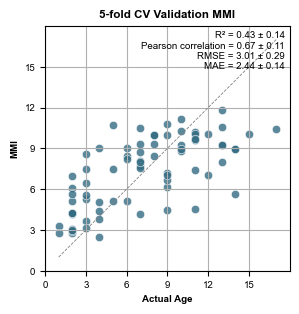


 trained data model importance feature Selection.
importance feature plot save complete.


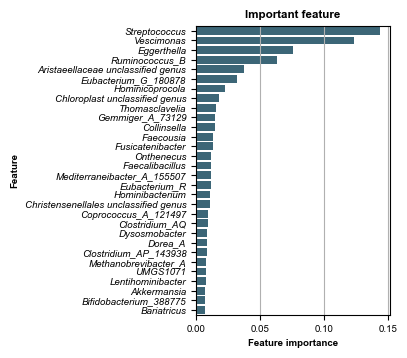


--- Transfer months to year traindata1 model---

--- Traindata traindata1 model evaluation ---
Testdata CV R²: 0.54
Testdata CV Pearson coefficient (R): 0.79 (p-value: 5.148e-05)
Testdata CV RMSE: 2.77
Testdata CV MAE: 2.09
[Saved]figure/1_microbiome_age_model/Testdata_year.pdf


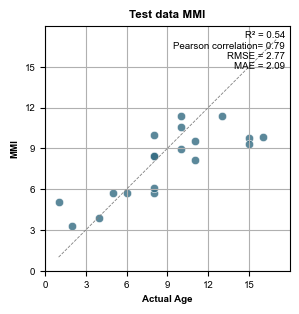


Train Dataset model save

Model save complete. path:'data/3-results/2_microbiome_age_model/italy-mam.joblib'

Start to train model SHAP Value Calculate


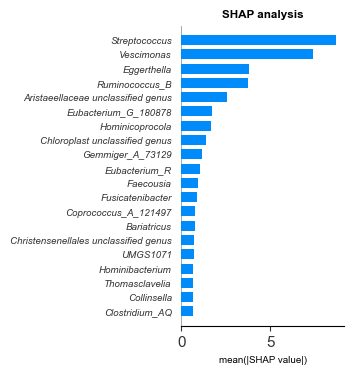

Complete model 20 shap bar plot save.


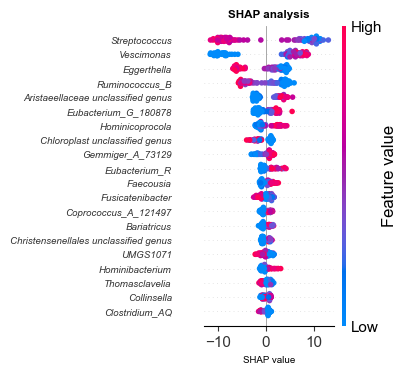

Complete model 20 shap dot plot save.
Importances features saved to data/3-results/2_microbiome_age_model/top30_feature.tsv
[Error] Save failed: All arrays must be of the same length

 Parameter information
RandomForestRegressor(max_depth=5, n_jobs=20, random_state=1234)


In [ ]:
# Model create and pipeline activation
# Adjust the n_splits_grid_search to the size of the dataset.
model_analyzer = MicrobiomeAgeModel(n_top_features=30, random_state=1234, n_splits_grid_search=5, test_size=0.2)
final_model = model_analyzer.run_pipeline(X = X_df, y = y_series, hue_data = y_series, model_save_path="data/3_results/2_microbiome_age_model/italy-mam.joblib", 
                                          top30_filepath="data/3_results/2_microbiome_age_model/top30_feature.tsv",
                                          shap_mean_filepath="data/3_results/2_microbiome_age_model/shap_mean_value.tsv")


print("\n Parameter information")
print(final_model)


# 3. Apply to PIBD Data

- Microbiome age model use to pibd data
- PIBD sample(60) and feature(187) import
    - This data also normalized by `1_normalization.ipynb`
        - log1p normalization and prevalence < 10% filtering


In [ ]:
pibd_table_path = 'data/2_preprocessed/log1p/prv10_ft_log1p_pibd.tsv'
pibd_meta_path = 'data/pre_metadata.tsv'
shannon_path = 'data/2_preprocessed/diversity/shannon.tsv'

pibd_table = pd.read_csv(pibd_table_path, sep='\t', index_col=0)
pibd_meta = pd.read_csv(pibd_meta_path, sep='\t').set_index('#SampleID')
pibd_meta = pibd_meta[(pibd_meta["Host_disease"] != "Control")]
pibd_meta = pibd_meta.dropna(subset=["Months"])
shannon = pd.read_csv(shannon_path, sep='\t').set_index('#SampleID')


pibd_common = pibd_table.index.intersection(pibd_meta.index)
pibd_otu = pibd_table.loc[pibd_common]
pibd_meta = pibd_meta.loc[pibd_common]
pibd_shannon = shannon.loc[pibd_common]
pibd_months_series = pibd_meta['Months']
pibd_X_df = pibd_otu.merge(pibd_shannon['shannon_entropy'], left_index=True, right_index=True)
pibd_y_series = pibd_months_series

print("X shape", pibd_X_df.shape)
print("y shape", pibd_y_series.shape)


X shape (49, 190)
y shape (49,)


## Applied to PIBD data about studied model
- use pibd data
- Table
    1. PIBD Microbiome Age Model results table file save
        - path: `/data/3_results/2_microbiome_age_model/pibd_results.tsv`
- figure
    1. pibd data Microbiome age model results figure.

load to model and feature
complete to load feature and model

PIBD patients MMI prediction
Complete
Start to Analysis and visualization
 - R2 Score: -2.2512
 - Pearson coefficient (R): 0.1388
 - RMSE: 7.2330
 - MAE: 6.3214


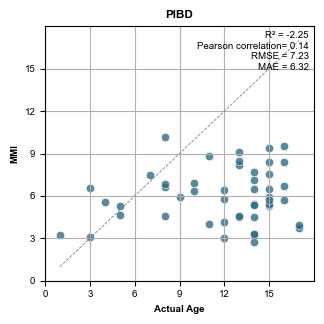


Start to SHAP Value Calculate


/home/pss8993/anaconda3/envs/py3_11/lib/python3.11/site-packages/shap/plots/_beeswarm.py:1153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()
/tmp/ipykernel_1102196/3749651522.py:107: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Complete SHAP calculate


In [ ]:
print("load to model and feature")
try:
    # model, feature path.
    model_path = "data/3_results/2_microbiome_age_model/italy-mam.joblib"
    loaded_model = joblib.load(model_path)


    X_df_list = list(X_df)
    print("complete to load feature and model")


except FileNotFoundError:
    print("Error. Check to model or feature table")
    exit()


def _simplify_taxonomy(name: str) -> str:
        # Family, Genus, Species
        if not isinstance(name, str) or ';' not in name:
            return name
        levels = name.split(';')
        selected = [level.strip() for level in levels if level.strip().startswith(('f__', 'g__', 's__'))]
        return '; '.join(selected)



# Feature match 
pibd_X_df = pibd_X_df.reindex(columns=X_df_list, fill_value=0)

# MMI Prediction
print("\nPIBD patients MMI prediction")
predicted_microbiome_age = loaded_model.predict(pibd_X_df)
print("Complete")


# Analysis and Visualization
print("Start to Analysis and visualization")

## Save to results by DataFrame
results_df = pd.DataFrame({
    '#SampleID': pibd_y_series.index,
    'real_age': pibd_y_series,
    'pred_age': predicted_microbiome_age,
    'real_year': (pibd_y_series / 12) - 0.5,
    'pred_year': (predicted_microbiome_age / 12) - 0.5
})
results_df['real_age'] = pd.to_numeric(results_df['real_age'], errors='coerce')

results_df = results_df.dropna()
results_df.to_csv('data/3_results/2_microbiome_age_model/pibd_results.tsv', sep='\t',index=False)


## MMI evaluation index calculate
valid_idx = results_df['real_age'].notnull()
mae = mean_absolute_error(results_df.loc[valid_idx, 'real_year'], results_df.loc[valid_idx, 'pred_year'])
r2 = r2_score(results_df.loc[valid_idx, 'real_year'], results_df.loc[valid_idx, 'pred_year'])
rmse_pibd = np.sqrt(mean_squared_error(results_df.loc[valid_idx, 'real_year'], results_df.loc[valid_idx, 'pred_year']))
r, p = pearsonr(results_df.loc[valid_idx, 'real_year'], results_df.loc[valid_idx, 'pred_year'])


print(f" - R2 Score: {r2:.4f}")
print(f" - Pearson coefficient (R): {r:.4f}")
print(f" - RMSE: {rmse_pibd:.4f}")
print(f" - MAE: {mae:.4f}")



pi_metrics_text = (
            f"R² = {r2:.2f}\n"
            f"Pearson correlation= {r:.2f}\n"
            f"RMSE = {rmse_pibd:.2f}\n"
            f"MAE = {mae:.2f}"
            )



## Visualization 1: real_age vs pred_age(MMI)
plt.figure(figsize=(3.25, 3.25))
color = sns.color_palette('pastel')
sns.scatterplot(data=results_df, x='real_year', y='pred_year', color = '#326a81', alpha=0.8)
plt.xlim(0,18)
plt.ylim(0,18)
plt.xticks(range(0, 18, 3))
plt.yticks(range(0, 18, 3))
plt.text(0.98, 0.98, pi_metrics_text, transform=plt.gca().transAxes, ha='right', va='top', fontsize=7)
plt.plot([1,17], [1,17], '--', color='gray')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.title('PIBD', fontweight='bold')
plt.xlabel('Actual Age', fontweight='bold')
plt.ylabel('MMI', fontweight='bold')
plt.grid()
plt.tight_layout()
plt.savefig('figure/1_microbiome_age_model/pibd_mmi_year.pdf',dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# SHAP
print("\nStart to SHAP Value Calculate")
explainer = shap.TreeExplainer(loaded_model)
shap_values = explainer.shap_values(pibd_X_df, check_additivity=False)
simplified_cols = [_simplify_taxonomy(name) for name in pibd_X_df.columns]
pibd_X_df_simplified = pibd_X_df.copy()
pibd_X_df_simplified.columns = simplified_cols

shap.summary_plot(shap_values, pibd_X_df, plot_type='bar', show = False)
plt.tight_layout()
plt.savefig('figure/1_microbiome_age_model/pibd_shap.pdf', dpi=300, bbox_inches="tight")
plt.close()
print("Complete SHAP calculate")





# 4. Make Results file

- Merge and save the resulting file(`model_results.tsv, pibd_results.tsv`) obtained by running the Microbiome age model.
- Save as `mmi.tsv` by adding host_sex, disease of metadata.
- path: `data/mmi.tsv`

In [ ]:
con = pd.read_csv("data/3_results/2_microbiome_age_model/model_results.tsv", sep='\t')
results_df = pd.read_csv("data/3_results/2_microbiome_age_model/pibd_results.tsv", sep='\t')

mmi = pd.concat([con,results_df], axis=0)


mmi['Months'] = mmi['real_age']




In [22]:
meta = pd.read_csv(meta_path, sep='\t')

meta_sub = meta[['#SampleID', 'host_sex', 'Host_disease', 'location_disease']]

merged_df = pd.merge(
    mmi,
    meta_sub,
    on='#SampleID',
    how='right'   # mmi criteria
)

merged_df = merged_df.dropna(subset=['pred_age'])

merged_df ## This merged_df don't have of mean mmi information.

,#SampleID,real_age,pred_age,real_year,pred_year,Months,host_sex,Host_disease,location_disease
0,SRR23478195,18.0,67.056213,1.0,5.088018,18.0,female,Control,Control(IT)
1,SRR23478196,18.0,45.697345,1.0,3.308112,18.0,male,Control,Control(IT)
2,SRR23478197,18.0,39.726962,1.0,2.810580,18.0,female,Control,Control(IT)
3,SRR23478198,30.0,57.056382,2.0,4.254699,30.0,male,Control,Control(IT)
4,SRR23478199,30.0,56.138670,2.0,4.178222,30.0,male,Control,Control(IT)
...,...,...,...,...,...,...,...,...,...
141,SRR23492553,186.0,69.300096,15.0,5.275008,186.0,NaN,ulcerative colitis,PIBD(IT)
142,SRR23492554,66.0,62.215929,5.0,4.684661,66.0,NaN,ulcerative colitis,PIBD(IT)
143,SRR23492555,150.0,55.532133,12.0,4.127678,150.0,NaN,ulcerative colitis,PIBD(IT)
144,SRR23492556,42.0,84.976783,3.0,6.581399,42.0,NaN,ulcerative colitis,PIBD(IT)


In [23]:
merged_df.count()

#SampleID           143
real_age            143
pred_age            143
real_year           143
pred_year           143
Months              143
host_sex            117
Host_disease        143
location_disease    143
dtype: int64

In [ ]:
mmi_means = merged_df[merged_df["Host_disease"] == "Control"].groupby("real_age")["pred_age"].mean().reset_index()

mmi_merge = merged_df.merge(mmi_means, on="real_age", how="left")

mmi_merge = mmi_merge.round(2)

mmi_merge.rename(columns={"pred_age_x":"mmi"}, inplace=True)
mmi_merge.rename(columns={"pred_age_y":"mean_age"}, inplace=True)

mmi_merge["Separation"] = np.where(
  mmi_merge["mmi"] < mmi_merge["mean_age"], "mmilow", "mmihigh"
)

mmi_merge['Host_disease'] = mmi_merge["Host_disease"].replace({
    "crohn's disease": "PIBD",
    "ulcerative colitis": "PIBD" ## If want separated by disease phenotype? replace at CD and UC
})

In [25]:
def assign_network(row):
    if isinstance(row['Host_disease'], str) and row['Host_disease'].lower() == 'control':
        return row['Separation']
    else:
        return row['Host_disease']

mmi_merge['Network'] = mmi_merge.apply(assign_network, axis=1)




In [26]:
mmi_merge

,#SampleID,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network
0,SRR23478195,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh
1,SRR23478196,18.0,45.70,1.0,3.31,18.0,male,Control,Control(IT),50.83,mmilow,mmilow
2,SRR23478197,18.0,39.73,1.0,2.81,18.0,female,Control,Control(IT),50.83,mmilow,mmilow
3,SRR23478198,30.0,57.06,2.0,4.25,30.0,male,Control,Control(IT),56.42,mmihigh,mmihigh
4,SRR23478199,30.0,56.14,2.0,4.18,30.0,male,Control,Control(IT),56.42,mmilow,mmilow
...,...,...,...,...,...,...,...,...,...,...,...,...
138,SRR23492553,186.0,69.30,15.0,5.28,186.0,NaN,PIBD,PIBD(IT),122.46,mmilow,PIBD
139,SRR23492554,66.0,62.22,5.0,4.68,66.0,NaN,PIBD,PIBD(IT),93.28,mmilow,PIBD
140,SRR23492555,150.0,55.53,12.0,4.13,150.0,NaN,PIBD,PIBD(IT),108.56,mmilow,PIBD
141,SRR23492556,42.0,84.98,3.0,6.58,42.0,NaN,PIBD,PIBD(IT),74.80,mmihigh,PIBD


In [27]:
mmi_merge["Group"] = mmi_merge.apply(
    lambda row: row["Separation"] if row["Host_disease"] == "Control" else row["Host_disease"],
    axis=1
)


In [ ]:
mmi_merge.to_csv("data/model.tsv", sep='\t')

In [28]:
mmi_merge["Network"].value_counts()

Network
PIBD       49
mmihigh    47
mmilow     47
Name: count, dtype: int64